|Machine Learning Lab 06                     |                   |          
|:------------------------------------------:|:-----------------:|
| **Logistic Regression on MNIST**           |                   |

|                 |                   | 
|-----------------|:-----------------:|
| **Name**        | Shubham Choudhary |        
| **Roll Number** | 212405015         |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from PIL import Image
import time

MAX_TRAIN = None
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Task 1 — Load, normalize, visualize, split

In [2]:
# 1. Load MNIST
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [3]:
X = X.astype(np.float32) / 255.0      # normalize to [0,1]
y = y.astype(np.int64)                # labels 0..9

In [4]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [5]:
X.shape

(70000, 784)

In [6]:
y

array([5, 0, 4, ..., 4, 5, 6])

In [7]:
y.shape

(70000,)

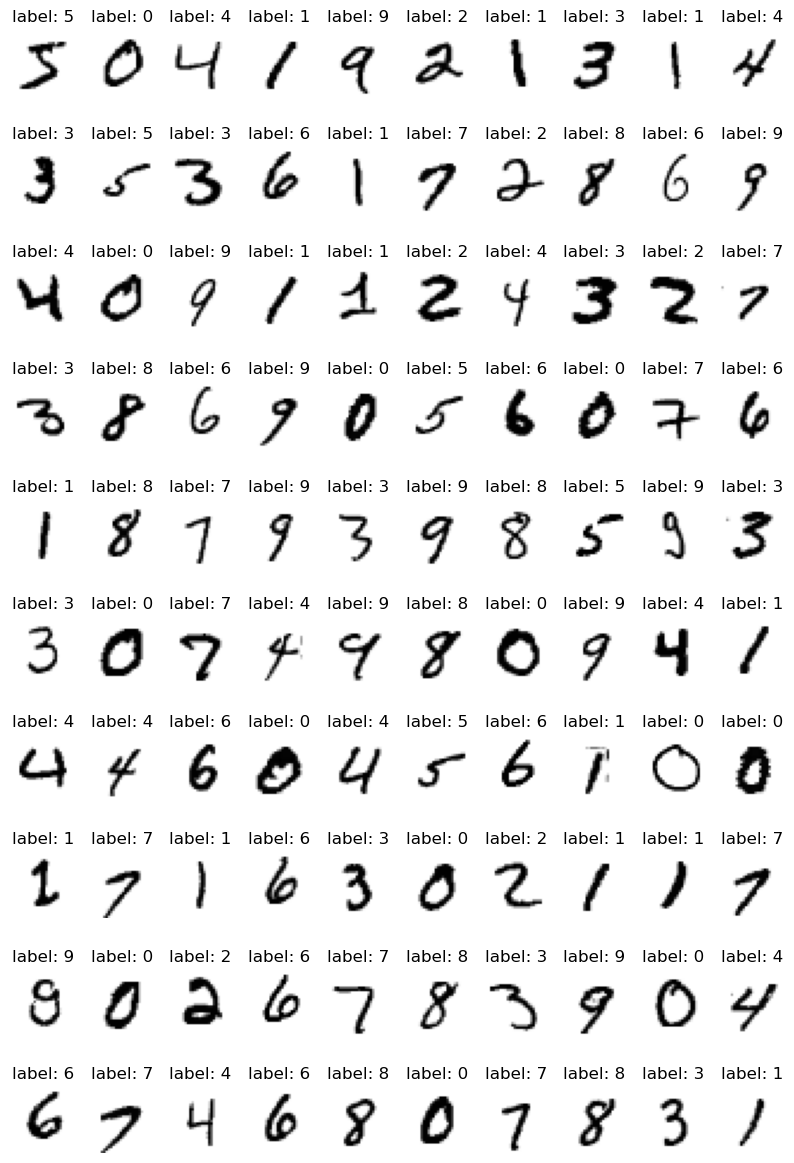

In [8]:
# 2. Visualize some samples
fig, axes = plt.subplots(10, 10, figsize=(10, 15))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28, 28), cmap='binary')
    ax.set_title(f"label: {y[i]}")
    ax.axis('off')
plt.show()

In [9]:
# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=10000, random_state=RANDOM_STATE, stratify=y)

## Task 2 – Multinomial logistic regression (softmax) from scratch

In [11]:
# Utility functions
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)   # numeric stability
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

def cross_entropy(y_true_onehot, probs, eps=1e-12):
    return -np.mean(np.sum(y_true_onehot * np.log(probs + eps), axis=1))

def one_hot(y, C):
    return np.eye(C, dtype=np.float32)[y]

# Softmax regression trainer (mini-batch SGD)
def train_softmax(X, y, n_classes=10, lr=0.1, epochs=30, batch_size=256, reg=1e-4, verbose=True):
    n_samples, n_features = X.shape
    W = np.random.randn(n_features, n_classes) * 0.01
    b = np.zeros(n_classes, dtype=np.float32)
    Y_one = one_hot(y, n_classes)
    loss_history = []

    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_sh = X[perm]
        Y_sh = Y_one[perm]

        for i in range(0, n_samples, batch_size):
            Xb = X_sh[i:i+batch_size]
            Yb = Y_sh[i:i+batch_size]
            logits = Xb.dot(W) + b
            probs = softmax(logits)
            diff = probs - Yb  # shape (batch, n_classes)

            gradW = Xb.T.dot(diff) / Xb.shape[0] + reg * W
            gradb = np.mean(diff, axis=0)

            W -= lr * gradW
            b -= lr * gradb

        # compute epoch loss on full training data (for curve)
        probs_all = softmax(X.dot(W) + b)
        loss = cross_entropy(Y_one, probs_all) + 0.5 * reg * np.sum(W * W)
        loss_history.append(loss)
        if verbose and (epoch % 5 == 0 or epoch == epochs-1):
            y_pred = np.argmax(probs_all, axis=1)
            acc = (y_pred == y).mean()
            print(f"Epoch {epoch+1}/{epochs} - loss: {loss:.4f} - train_acc: {acc:.4f}")

    return W, b, loss_history

def predict_softmax(X, W, b):
    probs = softmax(X.dot(W) + b)
    return np.argmax(probs, axis=1)


Epoch 1/30 - loss: 0.4719 - train_acc: 0.8795
Epoch 6/30 - loss: 0.3330 - train_acc: 0.9092
Epoch 11/30 - loss: 0.3083 - train_acc: 0.9163
Epoch 16/30 - loss: 0.2971 - train_acc: 0.9186
Epoch 21/30 - loss: 0.2912 - train_acc: 0.9202
Epoch 26/30 - loss: 0.2878 - train_acc: 0.9217
Epoch 30/30 - loss: 0.2826 - train_acc: 0.9235
Training finished in 24.1s


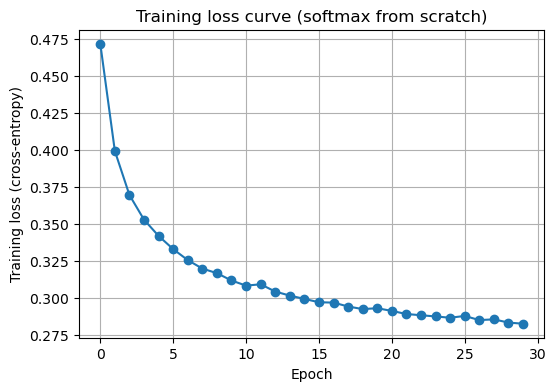

Softmax-from-scratch test accuracy: 0.9182


In [12]:
# Train softmax from scratch
t0 = time.time()
W, b, loss_hist = train_softmax(X_train, y_train, lr=0.2, epochs=30, batch_size=512, reg=1e-4, verbose=True)
print("Training finished in {:.1f}s".format(time.time() - t0))

# Plot training loss
plt.figure(figsize=(6,4))
plt.plot(loss_hist, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training loss (cross-entropy)")
plt.title("Training loss curve (softmax from scratch)")
plt.grid(True)
plt.show()

# Evaluate on test
y_test_pred = predict_softmax(X_test, W, b)
test_acc = accuracy_score(y_test, y_test_pred)
print("Softmax-from-scratch test accuracy: {:.4f}".format(test_acc))


## Task 3 – Effect of downsampling resolution

In [14]:
# Downsample an array of flattened 28x28 images to resolution res x res
def downsample_dataset(X_flat, res):
    n = X_flat.shape[0]
    out = np.zeros((n, res * res), dtype=np.float32)
    for i in range(n):
        img = (X_flat[i].reshape(28,28) * 255).astype(np.uint8)
        pil = Image.fromarray(img)
        pil_resized = pil.resize((res,res), resample=Image.BILINEAR)
        arr = np.asarray(pil_resized).astype(np.float32) / 255.0
        out[i] = arr.ravel()
    return out

resolutions = [28, 14, 7, 4, 2, 1]
lr_accuracies = []
knn_accuracies = []

# Optionally, reduce train/test sizes for heavy experiments
MAX_TRAIN_DS = None   # None means use full X_train as already set; set e.g. 5000 to speed up

for res in resolutions:
    print("\nResolution:", res, "x", res)
    # downsample
    Xtr_small = downsample_dataset(X_train if MAX_TRAIN_DS is None else X_train[:MAX_TRAIN_DS], res)
    ytr_small = y_train if MAX_TRAIN_DS is None else y_train[:MAX_TRAIN_DS]
    Xte_small = downsample_dataset(X_test, res)

    # 1) train softmax (fewer epochs for very small resolutions)
    epochs_for_res = 30 if res >= 14 else 20
    W_small, b_small, _ = train_softmax(Xtr_small, ytr_small, lr=0.2, epochs=epochs_for_res, batch_size=512, reg=1e-4, verbose=False)
    yte_pred_lr = predict_softmax(Xte_small, W_small, b_small)
    acc_lr = accuracy_score(y_test, yte_pred_lr)
    print(f" k-NN accuracy @ {res}x{res}: {acc_lr:.4f}")
    lr_accuracies.append(acc_lr)

    # 2) k-NN (k=3)
    knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
    knn.fit(Xtr_small, ytr_small)
    yte_pred_knn = knn.predict(Xte_small)
    acc_knn = accuracy_score(y_test, yte_pred_knn)
    print(f" Softmax accuracy @ {res}x{res}: {acc_knn:.4f}")
    knn_accuracies.append(acc_knn)



Resolution: 28 x 28
 k-NN accuracy @ 28x28: 0.9198
 Softmax accuracy @ 28x28: 0.9735

Resolution: 14 x 14
 k-NN accuracy @ 14x14: 0.9017
 Softmax accuracy @ 14x14: 0.9777

Resolution: 7 x 7
 k-NN accuracy @ 7x7: 0.8518
 Softmax accuracy @ 7x7: 0.9591

Resolution: 4 x 4
 k-NN accuracy @ 4x4: 0.6457
 Softmax accuracy @ 4x4: 0.8695

Resolution: 2 x 2
 k-NN accuracy @ 2x2: 0.2303
 Softmax accuracy @ 2x2: 0.3256

Resolution: 1 x 1
 k-NN accuracy @ 1x1: 0.1813
 Softmax accuracy @ 1x1: 0.1614


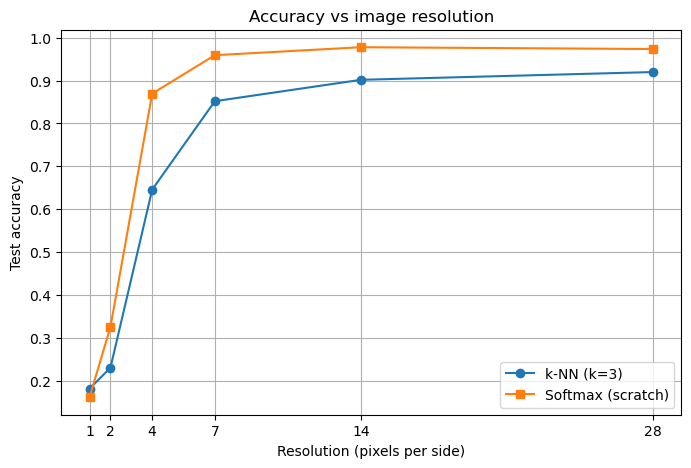

In [15]:
plt.figure(figsize=(8,5))
plt.plot(resolutions, lr_accuracies, marker='o', label='k-NN (k=3)')
plt.plot(resolutions, knn_accuracies, marker='s', label='Softmax (scratch)')
plt.xlabel("Resolution (pixels per side)")
plt.ylabel("Test accuracy")
plt.title("Accuracy vs image resolution")
plt.xticks(resolutions)
plt.grid(True)
plt.legend()
plt.show()

## Task 4 – Comparison with k-NN (extra k values)

In [16]:
# optional: explore k values at original resolution 28x28
k_values = [1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31]
Xtr_28 = downsample_dataset(X_train, 28)
Xte_28 = downsample_dataset(X_test, 28)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(Xtr_28, y_train)
    acc = knn.score(Xte_28, y_test)
    print(f"k={k} -> k-NN accuracy (28x28): {acc:.4f}")

k=1 -> k-NN accuracy (28x28): 0.9727
k=3 -> k-NN accuracy (28x28): 0.9735
k=5 -> k-NN accuracy (28x28): 0.9717
k=7 -> k-NN accuracy (28x28): 0.9702
k=9 -> k-NN accuracy (28x28): 0.9672
k=11 -> k-NN accuracy (28x28): 0.9669
k=13 -> k-NN accuracy (28x28): 0.9659
k=15 -> k-NN accuracy (28x28): 0.9643
k=17 -> k-NN accuracy (28x28): 0.9626
k=19 -> k-NN accuracy (28x28): 0.9615
k=21 -> k-NN accuracy (28x28): 0.9609
k=23 -> k-NN accuracy (28x28): 0.9589
k=25 -> k-NN accuracy (28x28): 0.9583
k=27 -> k-NN accuracy (28x28): 0.9574
k=29 -> k-NN accuracy (28x28): 0.9569
k=31 -> k-NN accuracy (28x28): 0.9558


## Task 5 – Interpretability: confusion matrix and weight visualization

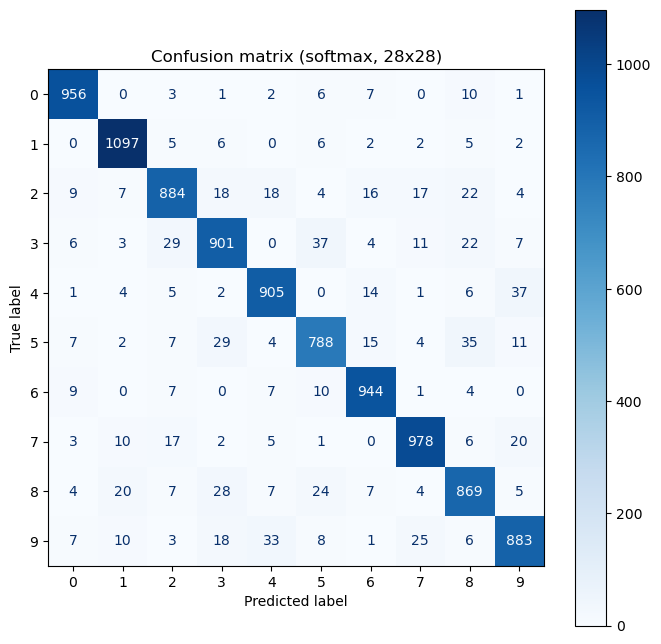

Top 10 mis-classified pairs (count, true, predicted):
37 4 -> 9
37 3 -> 5
35 5 -> 8
33 9 -> 4
29 5 -> 3
29 3 -> 2
28 8 -> 3
25 9 -> 7
24 8 -> 5
22 3 -> 8


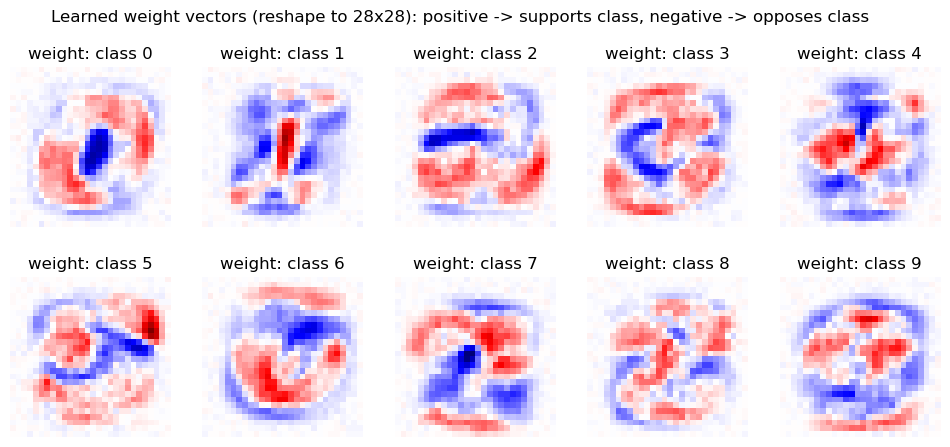

Class 0 top 10 pixels (row,col): [(15, 14), (13, 15), (14, 15), (16, 14), (16, 13), (15, 15), (12, 15), (14, 14), (14, 16), (13, 16)]
Class 1 top 10 pixels (row,col): [(12, 14), (13, 14), (11, 14), (11, 15), (14, 14), (15, 14), (12, 15), (16, 14), (10, 15), (10, 14)]
Class 2 top 10 pixels (row,col): [(11, 13), (13, 6), (12, 7), (12, 6), (11, 12), (13, 7), (11, 10), (11, 11), (12, 9), (12, 12)]
Class 3 top 10 pixels (row,col): [(17, 10), (10, 10), (18, 12), (17, 9), (10, 11), (18, 11), (18, 10), (17, 11), (10, 9), (10, 12)]
Class 4 top 10 pixels (row,col): [(13, 11), (10, 14), (9, 14), (12, 11), (11, 14), (17, 14), (16, 15), (14, 17), (12, 12), (13, 10)]
Class 5 top 10 pixels (row,col): [(9, 24), (10, 24), (8, 24), (9, 25), (10, 25), (12, 22), (9, 23), (12, 21), (7, 24), (8, 23)]
Class 6 top 10 pixels (row,col): [(9, 18), (9, 19), (8, 19), (9, 17), (17, 11), (21, 13), (8, 18), (21, 14), (10, 17), (19, 11)]
Class 7 top 10 pixels (row,col): [(13, 13), (13, 12), (14, 12), (14, 13), (14, 11

In [17]:
# Confusion matrix for softmax model trained at full 28x28 (W,b earlier from Task 2)
# If you re-trained W,b for 28x28 above, use that. Otherwise retrain quickly:
W_full, b_full, _ = train_softmax(downsample_dataset(X_train, 28), y_train, lr=0.2, epochs=30, batch_size=512, reg=1e-4, verbose=False)
y_pred_full = predict_softmax(downsample_dataset(X_test,28), W_full, b_full)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_full)
disp = ConfusionMatrixDisplay(cm, display_labels=np.arange(10))
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title("Confusion matrix (softmax, 28x28)")
plt.show()

# Identify most confused pairs (off-diagonal large counts)
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
pairs = []
for i in range(10):
    for j in range(10):
        if i!=j:
            pairs.append((cm_offdiag[i,j], i, j))
pairs_sorted = sorted(pairs, reverse=True)
print("Top 10 mis-classified pairs (count, true, predicted):")
for count, t, p in pairs_sorted[:10]:
    print(count, t, "->", p)

# Visualize learned weight vectors (class prototypes)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c, ax in enumerate(axes.ravel()):
    ax.imshow(W_full[:, c].reshape(28, 28), cmap='seismic', vmin=-np.max(np.abs(W_full)), vmax=np.max(np.abs(W_full)))
    ax.set_title(f"weight: class {c}")
    ax.axis('off')
plt.suptitle("Learned weight vectors (reshape to 28x28): positive -> supports class, negative -> opposes class")
plt.show()

# Which pixels are most important for each digit?
top_k = 10
for c in range(10):
    w = W_full[:, c]
    idx_top = np.argsort(np.abs(w))[::-1][:top_k]
    coords = [(int(i/28), int(i%28)) for i in idx_top]
    print(f"Class {c} top {top_k} pixels (row,col): {coords}")
